#NLP Expriment 2
Hassaan Shaikh

242A007

In [1]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random
import pandas as pd

In [2]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [3]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [4]:
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [5]:
print(f'Number of positive tweets: {len(all_positive_tweets)}')
print(f'Number of negative tweets: {len(all_negative_tweets)}')
print("Doug was here...")
print('\nThe type of all_positive_tweets is: ', type(all_positive_tweets))
print('The type of a tweet entry is: ', type(all_positive_tweets[0]))

Number of positive tweets: 5000
Number of negative tweets: 5000
Doug was here...

The type of all_positive_tweets is:  <class 'list'>
The type of a tweet entry is:  <class 'str'>


In [6]:
all_positive_tweets_df = pd.DataFrame(all_positive_tweets, columns=["Tweets"])
all_negative_tweets_df = pd.DataFrame(all_negative_tweets, columns=["Tweets"])

In [7]:
all_positive_tweets_df.head()

,Tweets
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...
1,@Lamb2ja Hey James! How odd :/ Please call our...
2,@DespiteOfficial we had a listen last night :)...
3,@97sides CONGRATS :)
4,yeaaaah yippppy!!! my accnt verified rqst has...


In [8]:
all_negative_tweets_df.head()

,Tweets
0,hopeless for tmr :(
1,Everything in the kids section of IKEA is so c...
2,@Hegelbon That heart sliding into the waste ba...
3,"“@ketchBurning: I hate Japanese call him ""bani..."
4,"Dang starting next week I have ""work"" :("


In [9]:
all_positive_tweets_df.shape

(5000, 1)

In [10]:
all_negative_tweets_df.shape

(5000, 1)

In [11]:
all_positive_tweets_df["Sentiment"] = "Positive"
all_negative_tweets_df["Sentiment"] = "Negative"

In [12]:
all_positive_tweets_df.head()

,Tweets,Sentiment
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,Positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,Positive
2,@DespiteOfficial we had a listen last night :)...,Positive
3,@97sides CONGRATS :),Positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,Positive


In [13]:
all_negative_tweets_df.head()

,Tweets,Sentiment
0,hopeless for tmr :(,Negative
1,Everything in the kids section of IKEA is so c...,Negative
2,@Hegelbon That heart sliding into the waste ba...,Negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",Negative
4,"Dang starting next week I have ""work"" :(",Negative


In [14]:
all_tweets_df = pd.concat([all_positive_tweets_df, all_negative_tweets_df], ignore_index = True)
all_tweets_df

,Tweets,Sentiment
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,Positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,Positive
2,@DespiteOfficial we had a listen last night :)...,Positive
3,@97sides CONGRATS :),Positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,Positive
...,...,...
9995,I wanna change my avi but uSanele :(,Negative
9996,MY PUPPY BROKE HER FOOT :(,Negative
9997,where's all the jaebum baby pictures :((,Negative
9998,But but Mr Ahmad Maslan cooks too :( https://t...,Negative


In [15]:
all_tweets_df = all_tweets_df.sample(frac = 1).reset_index(drop=True)
all_tweets_df

,Tweets,Sentiment
0,@beamiller I can't listen to your new album on...,Negative
1,"Ah ma guy. You know the thing. ""@ceafive: the ...",Negative
2,finding old pictures with my long hair makes m...,Negative
3,"@amerazjm FOLLOWED ME THANKS, AND\n@justinbieb...",Negative
4,@JackFejer thanks :),Positive
...,...,...
9995,@AnnieIsDoomed its not my fault sweedy :(,Negative
9996,"Playing ""Give Your Heart A Break"" having memor...",Negative
9997,Always motivated :-),Positive
9998,eric &amp; i made up and he still didn't tell ...,Negative


In [16]:
tweet1 = all_tweets_df.iloc[random.randint(0, len(all_tweets_df['Tweets']))]
tweet1["Tweets"]

'Nobody :) likes :) me :)'

In [17]:
y_positive = (all_tweets_df["Sentiment"] == "Positive").sum()

In [18]:
y_negative = (all_tweets_df["Sentiment"] == "Negative").sum()

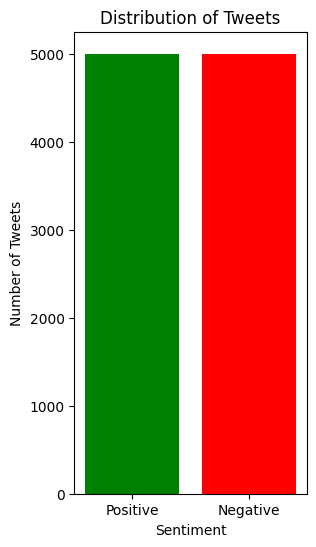

In [19]:
fig = plt.figure(figsize = (3, 6))
labels = 'Positive', 'Negative'
sizes = [y_positive, y_negative]
plt.bar(labels, sizes, color = ['green', 'red'])
plt.title("Distribution of Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

#Preprocessing

In [20]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [22]:
tweet2 = re.sub(r'^RT[\s]+', '', tweet1["Tweets"])
tweet2 = re.sub(r'https?:\/\/.[^\s\n\r]+', '', tweet2)
tweet2 = re.sub(r'#', '', tweet2)
tweet2 = re.sub(r'@', '', tweet2)
tweet2 = re.sub(r':\)|:\(', '', tweet2)
print("Cleaned tweet: ", tweet2)

Cleaned tweet:  Nobody  likes  me 


In [23]:
tokenizer = TweetTokenizer(preserve_case = False, strip_handles = True, reduce_len = True)
tweet_tokens = tokenizer.tokenize(tweet2)
print("Tokenized String:\n", tweet_tokens)

Tokenized String:
 ['nobody', 'likes', 'me']


In [24]:
stopwords_english = stopwords.words('english')
print("English Stop words:\n", stopwords_english)

print("Punctuation: ", string.punctuation)

English Stop words:
 ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', '

In [25]:
print(tweet_tokens)
print()
cleaned_tweets = []

for word in tweet_tokens:
  if (word not in stopwords_english and word not in string.punctuation):
    cleaned_tweets.append(word)

print("Removed stopwords and punctuation:\n", cleaned_tweets)

['nobody', 'likes', 'me']

Removed stopwords and punctuation:
 ['nobody', 'likes']


In [26]:
def process_tweet(tweet):
  tweet = re.sub(r'^RT[\s]+', '', tweet)
  tweet = re.sub(r'https?:\/\/.[^\s\n\r]+', '', tweet)
  tweet = re.sub(r'#', '', tweet)
  tweet = re.sub(r'@', '', tweet)
  tweet = re.sub(r':\)|:\(', '', tweet)
  tweet_tokens = tokenizer.tokenize(tweet)
  stopwords_english = stopwords.words('english')
  cleaned_tweet = []
  for word in tweet_tokens:
    if (word not in stopwords_english and word not in string.punctuation):
      cleaned_tweet.append(word)
  return cleaned_tweet

In [27]:
random_tweet = all_tweets_df.iloc[random.randint(0, len(all_tweets_df['Tweets']))]
print(f"Original Tweet: {random_tweet["Tweets"]}")
print(f"Cleaned Tweet: {process_tweet(random_tweet["Tweets"])}")

Original Tweet: @clemencycox i want a sausage roll :-(
Cleaned Tweet: ['clemencycox', 'want', 'sausage', 'roll', ':-(']


In [28]:
processed_tweets = all_tweets_df['Tweets'].apply(process_tweet)
all_tweets_df['Processed Tweets'] = processed_tweets
pd.set_option('display.max_colwidth', None)
all_tweets_df

,Tweets,Sentiment,Processed Tweets
0,@beamiller I can't listen to your new album on youtube because it's blocked in my country :(,Negative,"[beamiller, can't, listen, new, album, youtube, blocked, country]"
1,"Ah ma guy. You know the thing. ""@ceafive: the weather is set for more sleep but responsibilities. :-(""",Negative,"[ah, guy, know, thing, ceafive, weather, set, sleep, responsibilities, :-(]"
2,finding old pictures with my long hair makes me so sad :(,Negative,"[finding, old, pictures, long, hair, makes, sad]"
3,"@amerazjm FOLLOWED ME THANKS, AND\n@justinbieber PLEASE FOLLOWED ME TOO :(",Negative,"[amerazjm, followed, thanks, justinbieber, please, followed]"
4,@JackFejer thanks :),Positive,"[jackfejer, thanks]"
...,...,...,...
9995,@AnnieIsDoomed its not my fault sweedy :(,Negative,"[annieisdoomed, fault, sweedy]"
9996,"Playing ""Give Your Heart A Break"" having memories from ""The Breakup"" episode :( I love the song tho",Negative,"[playing, give, heart, break, memories, breakup, episode, love, song, tho]"
9997,Always motivated :-),Positive,"[always, motivated, :-)]"
9998,eric &amp; i made up and he still didn't tell me he loved me :-( fake ass,Negative,"[eric, made, still, tell, loved, :-(, fake, ass]"


In [30]:
all_processed_tweets = all_tweets_df[['Processed Tweets', 'Sentiment']]
all_processed_tweets

,Processed Tweets,Sentiment
0,"[beamiller, can't, listen, new, album, youtube, blocked, country]",Negative
1,"[ah, guy, know, thing, ceafive, weather, set, sleep, responsibilities, :-(]",Negative
2,"[finding, old, pictures, long, hair, makes, sad]",Negative
3,"[amerazjm, followed, thanks, justinbieber, please, followed]",Negative
4,"[jackfejer, thanks]",Positive
...,...,...
9995,"[annieisdoomed, fault, sweedy]",Negative
9996,"[playing, give, heart, break, memories, breakup, episode, love, song, tho]",Negative
9997,"[always, motivated, :-)]",Positive
9998,"[eric, made, still, tell, loved, :-(, fake, ass]",Negative
